# results: fairness and bias over time

In [1]:
# imports
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# WILDS
from wilds import get_dataset

In [2]:
# paths
OUT_DIR = "results_fairness_over_time"
SUMMARY_CSV = os.path.join(OUT_DIR, "summary_all_models.csv")
GROUPS_CSV  = os.path.join(OUT_DIR, "groups_all_models.csv")
BIAS_CSV    = os.path.join(OUT_DIR, "bias_crows_pairs.csv")

IDX_PATH  = "eval_idx.npy"
TEST_PATH = "test_idx.npy"

In [3]:
# CI config
N_BOOT = 400       # 200-1000, trade speed vs stability
CI_ALPHA = 0.05    # 95% CI
BOOT_SEED = 123

# identity groups (must match your run notebook)
identity_names = ["male", "female", "LGBTQ", "christian", "muslim", "other_religions", "black", "white"]

In [4]:
# load CSV
df_sum = pd.read_csv(SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_groups = pd.read_csv(GROUPS_CSV).sort_values(["year", "model_id", "group"]).reset_index(drop=True)


In [5]:
# compute fairness
def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]
    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"], out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"], out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"], out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"], out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"], out["pos_rate_var_recalc"],
        out["fpr_var_recalc"], out["fnr_var_recalc"]
    ]))
    return out

recalc_rows = []
for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
    row = {"year": int(year), "model_id": str(model_id)}
    row.update(fairness_from_groups(df_gm))
    recalc_rows.append(row)

df_recalc = pd.DataFrame(recalc_rows)
df = df_sum.merge(df_recalc, on=["year", "model_id"], how="left").sort_values(["year", "model_id"]).reset_index(drop=True)

# what fairness column do we want to plot?
FAIR_ABS = "avg_minmax_abs"  

In [6]:
# merge bias (CrowS)
df_bias = pd.read_csv(BIAS_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)

df["year"] = df["year"].astype(int)
df["model_id"] = df["model_id"].astype(str)
df_bias["year"] = df_bias["year"].astype(int)
df_bias["model_id"] = df_bias["model_id"].astype(str)

df = df.merge(df_bias[["year", "model_id", "crows_bias"]], on=["year", "model_id"], how="left")
print("Missing bias rows:", df["crows_bias"].isna().sum(), "/", len(df))

Missing bias rows: 1 / 25


In [7]:
# helper functions
def scatter_models_legend(df, xcol, ycol, title, xlabel, ylabel, x_is_year=False):
    fig, ax = plt.subplots(figsize=(15, 6))
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)
    fontsize = 8 if df["model_id"].nunique() <= 20 else 6

    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=fontsize)
    fig.tight_layout(rect=[0, 0, 0.75, 1])
    plt.show()

def scatter_models_legend_ci(df, xcol, ycol, ylo, yhi, title, xlabel, ylabel, x_is_year=False):
    fig, ax = plt.subplots(figsize=(15, 6))
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        lo = sub[ylo].astype(float)
        hi = sub[yhi].astype(float)

        ok = (~np.isnan(y)) & (~np.isnan(lo)) & (~np.isnan(hi)) & (~np.isnan(x))
        if ok.sum() == 0:
            continue

        x = x[ok]; y = y[ok]; lo = lo[ok]; hi = hi[ok]
        yerr = np.vstack([y - lo, hi - y])
        ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=2, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)
    fontsize = 8 if df["model_id"].nunique() <= 20 else 6
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=fontsize)
    fig.tight_layout(rect=[0, 0, 0.75, 1])
    plt.show()


In [8]:
# bias CI (Wilson interval)
# use only crow_bias % + N_pairs
def wilson_ci(k, n, alpha=0.05):
    # returns (lo, hi) for proportion in [0,1]
    if n <= 0:
        return (np.nan, np.nan)
    z = 1.959963984540054  # approx 97.5% quantile for normal
    # if you want exact z from scipy: from scipy.stats import norm; z = norm.ppf(1-alpha/2)
    p = k / n
    denom = 1 + (z*z)/n
    center = (p + (z*z)/(2*n)) / denom
    half = (z / denom) * np.sqrt((p*(1-p)/n) + (z*z)/(4*n*n))
    return (max(0.0, center - half), min(1.0, center + half))

def get_crows_pairs_n():
    # tries local CSV first, else HF datasets
    local = "crows_pairs_anonymized.csv"
    if os.path.exists(local):
        d = pd.read_csv(local)
        return int(len(d))
    try:
        from datasets import load_dataset
        ds = load_dataset("crows_pairs", split="test")
        return int(len(ds))
    except Exception:
        return None

N_PAIRS = get_crows_pairs_n()
print("CrowS-Pairs N pairs:", N_PAIRS)

if N_PAIRS is not None and "crows_bias" in df.columns:
    bias_lo = []
    bias_hi = []
    for v in df["crows_bias"].to_numpy():
        if np.isnan(v):
            bias_lo.append(np.nan); bias_hi.append(np.nan)
            continue
        p = float(v) / 100.0
        k = int(round(p * N_PAIRS))
        lo, hi = wilson_ci(k, N_PAIRS, alpha=CI_ALPHA)
        bias_lo.append(100.0 * lo)
        bias_hi.append(100.0 * hi)
    df["crows_bias_ci_lo"] = bias_lo
    df["crows_bias_ci_hi"] = bias_hi

CrowS-Pairs N pairs: 1508


In [9]:
# fairness and accuracy bootstrap CIs
def slugify_model_id(model_id: str) -> str:
    s = model_id.strip()
    s = s.replace("/", "__")
    s = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", s)
    return s[:180]

def confusion_rates(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    pos_rate = y_pred.mean() if len(y_pred) else np.nan
    acc = (y_true == y_pred).mean() if len(y_pred) else np.nan

    return {"acc": acc, "pos_rate": pos_rate, "fpr": fpr, "fnr": fnr}

def summarize_across_groups_dict(values_by_group, eps=1e-12):
    vals = np.array([v for v in values_by_group.values() if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def compute_overall_and_fairness(y_true_test, y_pred_test, group_masks_test: dict):
    overall = confusion_rates(y_true_test, y_pred_test)

    group_stats = {}
    for g, mask in group_masks_test.items():
        group_stats[g] = confusion_rates(y_true_test[mask], y_pred_test[mask])

    fairness = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = {g: group_stats[g][metric] for g in group_stats}
        fairness[metric] = summarize_across_groups_dict(vals)

    avg_minmax_abs = float(np.nanmean([fairness[m]["minmax_abs"] for m in ["acc","pos_rate","fpr","fnr"]]))
    avg_var        = float(np.nanmean([fairness[m]["var"]        for m in ["acc","pos_rate","fpr","fnr"]]))

    return overall, fairness, {"avg_minmax_abs": avg_minmax_abs, "avg_var": avg_var}

def bootstrap_ci_for_model(y_true_test, y_pred_test, group_masks_test, n_boot=400, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true_test)

    acc_samples = np.empty(n_boot, dtype=float)
    gap_samples = np.empty(n_boot, dtype=float)
    var_samples = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)

        y_t = y_true_test[idx]
        y_p = y_pred_test[idx]
        masks_b = {g: mask[idx] for g, mask in group_masks_test.items()}

        overall, fairness, agg = compute_overall_and_fairness(y_t, y_p, masks_b)
        acc_samples[b] = overall["acc"]
        gap_samples[b] = agg["avg_minmax_abs"]
        var_samples[b] = agg["avg_var"]

    lo = 100 * (alpha / 2)
    hi = 100 * (1 - alpha / 2)

    return {
        "test_acc_ci_lo": float(np.nanpercentile(acc_samples, lo)),
        "test_acc_ci_hi": float(np.nanpercentile(acc_samples, hi)),
        "avg_minmax_abs_ci_lo": float(np.nanpercentile(gap_samples, lo)),
        "avg_minmax_abs_ci_hi": float(np.nanpercentile(gap_samples, hi)),
        "avg_var_ci_lo": float(np.nanpercentile(var_samples, lo)),
        "avg_var_ci_hi": float(np.nanpercentile(var_samples, hi)),
    }

def can_do_bootstrap_ci():
    if not os.path.exists(IDX_PATH) or not os.path.exists(TEST_PATH):
        return False
    if not os.path.isdir(OUT_DIR):
        return False
    return True

if can_do_bootstrap_ci():
    eval_idx = np.load(IDX_PATH)
    test_subidx = np.load(TEST_PATH)

    dataset = get_dataset(dataset="civilcomments", download=True)
    test_data = dataset.get_subset("test", transform=None)

    y_true_eval = []
    meta_eval = []

    for i in eval_idx:
        _, y, m = test_data[int(i)]
        y_true_eval.append(int(y))
        meta_eval.append(m.numpy() if hasattr(m, "numpy") else np.array(m))

    y_true_eval = np.array(y_true_eval, dtype=int)
    meta_eval = np.stack(meta_eval, axis=0)

    # map identity columns
    field_lc = [f.lower() for f in dataset.metadata_fields]
    identity_cols = {}
    for name in identity_names:
        hits = [j for j, f in enumerate(field_lc) if name.lower() in f]
        identity_cols[name] = hits[0] if hits else None

    y_true_test_base = y_true_eval[test_subidx]

    group_masks_test_base = {}
    for g, col in identity_cols.items():
        if col is None:
            continue
        group_masks_test_base[g] = (meta_eval[test_subidx, col].astype(int) == 1)

    ci_rows = []
    for r in df_sum.itertuples(index=False):
        year = int(r.year)
        model_id = str(r.model_id)
        thr = float(r.threshold_t)

        p_path = os.path.join(OUT_DIR, f"p_toxic_{year}__{slugify_model_id(model_id)}.npy")
        if not os.path.exists(p_path):
            continue

        p_eval = np.load(p_path)
        y_pred_eval = (p_eval >= thr).astype(int)
        y_pred_test = y_pred_eval[test_subidx]

        seed = BOOT_SEED + (abs(hash(model_id)) % 10000) + year
        ci = bootstrap_ci_for_model(
            y_true_test_base,
            y_pred_test,
            group_masks_test_base,
            n_boot=N_BOOT,
            alpha=CI_ALPHA,
            seed=seed
        )

        row = {"year": year, "model_id": model_id}
        row.update(ci)
        ci_rows.append(row)

    df_ci = pd.DataFrame(ci_rows)
    df = df.merge(df_ci, on=["year", "model_id"], how="left")
    print("Bootstrap CI computed for:", len(df_ci), "models")
else:
    print("Skipping bootstrap CIs (missing eval_idx.npy/test_idx.npy or OUT_DIR).")

Bootstrap CI computed for: 25 models


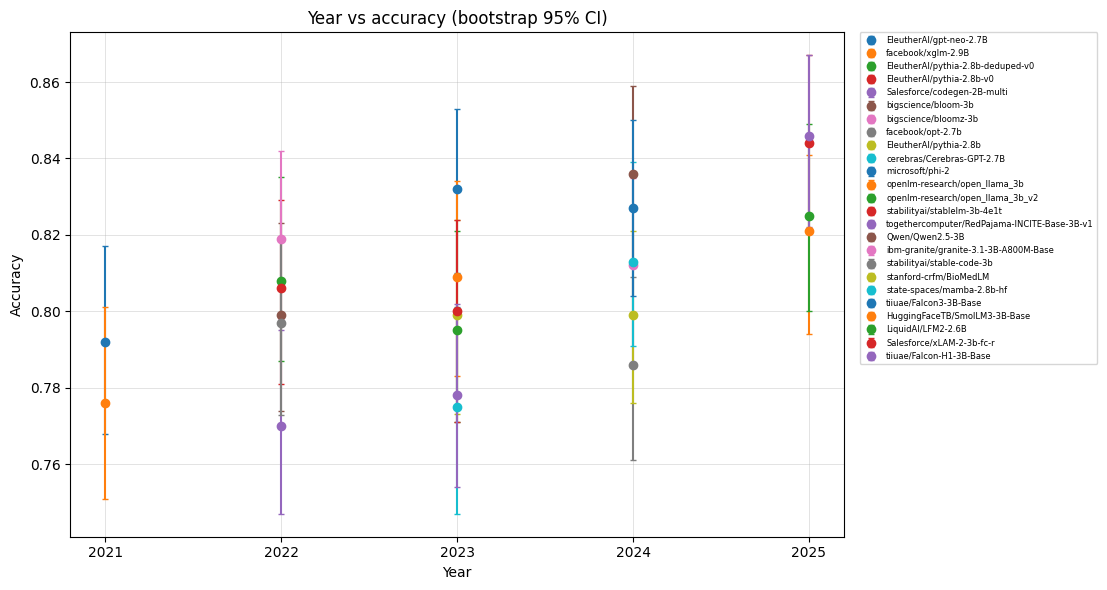

ValueError: 'yerr' must not contain negative values

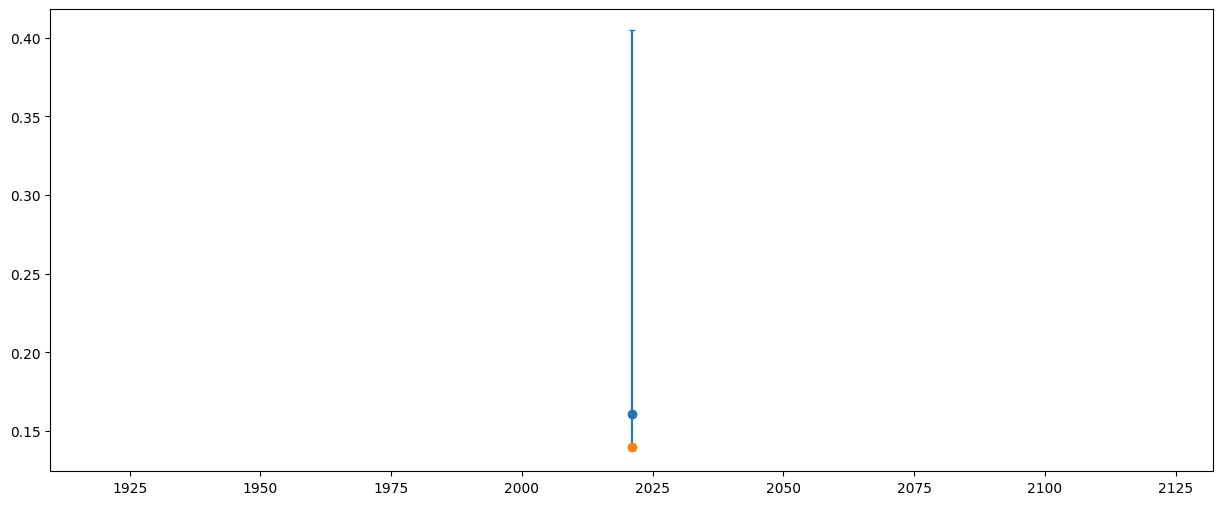

In [10]:
# plots with CI
# Accuracy over time (CI)
if {"test_acc_ci_lo","test_acc_ci_hi"}.issubset(df.columns):
    scatter_models_legend_ci(
        df, "year", "test_acc", "test_acc_ci_lo", "test_acc_ci_hi",
        "Year vs accuracy (bootstrap 95% CI)", "Year", "Accuracy", x_is_year=True
    )
else:
    scatter_models_legend(
        df, "year", "test_acc",
        "Year vs accuracy (test split)", "Year", "Accuracy", x_is_year=True
    )

# Fairness over time (CI on avg_minmax_abs)
if {"avg_minmax_abs_ci_lo","avg_minmax_abs_ci_hi"}.issubset(df.columns):
    scatter_models_legend_ci(
        df, "year", FAIR_ABS, "avg_minmax_abs_ci_lo", "avg_minmax_abs_ci_hi",
        "Year vs fairness (avg min-max abs gap, bootstrap 95% CI)", "Year", "Avg min-max abs gap", x_is_year=True
    )
else:
    scatter_models_legend(
        df, "year", FAIR_ABS,
        "Year vs fairness (avg min-max abs gap, lower = more fair)", "Year", "Avg min-max abs gap", x_is_year=True
    )

# Accuracy vs fairness (CI on fairness only)
if {"avg_minmax_abs_ci_lo","avg_minmax_abs_ci_hi"}.issubset(df.columns):
    scatter_models_legend_ci(
        df, "test_acc", FAIR_ABS, "avg_minmax_abs_ci_lo", "avg_minmax_abs_ci_hi",
        "Accuracy vs fairness (fairness bootstrap 95% CI)", "Accuracy", "Avg min-max abs gap", x_is_year=False
    )
else:
    scatter_models_legend(
        df, "test_acc", FAIR_ABS,
        "Accuracy vs fairness (avg min-max abs gap)", "Accuracy", "Avg min-max abs gap", x_is_year=False
    )

# Bias over time (CI if N_PAIRS available)
if {"crows_bias_ci_lo","crows_bias_ci_hi"}.issubset(df.columns):
    scatter_models_legend_ci(
        df, "year", "crows_bias", "crows_bias_ci_lo", "crows_bias_ci_hi",
        "Year vs CrowS-style bias (Wilson 95% CI)", "Year", "CrowS-style bias (%)", x_is_year=True
    )
else:
    scatter_models_legend(
        df, "year", "crows_bias",
        "Year vs CrowS-style bias", "Year", "CrowS-style bias (%)", x_is_year=True
    )

# Accuracy vs bias (CI if N_PAIRS available)
if {"crows_bias_ci_lo","crows_bias_ci_hi"}.issubset(df.columns):
    scatter_models_legend_ci(
        df, "test_acc", "crows_bias", "crows_bias_ci_lo", "crows_bias_ci_hi",
        "Accuracy vs CrowS-style bias (Wilson 95% CI)", "Accuracy", "CrowS-style bias (%)", x_is_year=False
    )
else:
    scatter_models_legend(
        df, "test_acc", "crows_bias",
        "Accuracy vs CrowS-style bias", "Accuracy", "CrowS-style bias (%)", x_is_year=False
    )

